<a href="https://colab.research.google.com/github/gerenciaracemachine-cpu/regresiones-lineales/blob/main/Machine_Learnin_ML_supervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.datasets import make_classification

In [4]:
X, y = make_classification(
    n_samples=1000,
    n_features=4,
    n_informative=3,
    n_redundant=1,
    random_state=42
)

In [5]:
features = ['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
df = pd.DataFrame(X, columns=features)
df['Target'] = y

print("=== Primeras filas del conjunto de datos ===")
print(df.head())
print("\n" + "="*50 + "\n")

=== Primeras filas del conjunto de datos ===
   Feature_1  Feature_2  Feature_3  Feature_4  Target
0   0.980832   0.408410   1.168098  -0.123571       1
1   0.445277  -1.986198   0.219744   1.869351       0
2  -1.892225  -1.032171   1.541761  -0.175732       0
3   0.081571  -2.216266  -0.718966   2.066282       0
4   1.454131   0.605897   0.629691  -0.002079       1




In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
modelo = LogisticRegression(random_state=42)
modelo.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [8]:
y_pred = modelo.predict(X_test)

In [9]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
matriz_conf = confusion_matrix(y_test, y_pred)

print("=== RESULTADOS Y MÉTRICAS DE EVALUACIÓN ===")
print(f"Accuracy (Exactitud General) : {accuracy:.4f}")
print(f"Precision (Precisión)       : {precision:.4f}")
print(f"Recall (Sensibilidad)       : {recall:.4f}")
print("\n--- Reporte de Clasificación Detallado ---")
print(classification_report(y_test, y_pred))

=== RESULTADOS Y MÉTRICAS DE EVALUACIÓN ===
Accuracy (Exactitud General) : 0.9000
Precision (Precisión)       : 0.8990
Recall (Sensibilidad)       : 0.8990

--- Reporte de Clasificación Detallado ---
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       101
           1       0.90      0.90      0.90        99

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



In [10]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(50.722222222222214, 0.5, 'Valor Real')

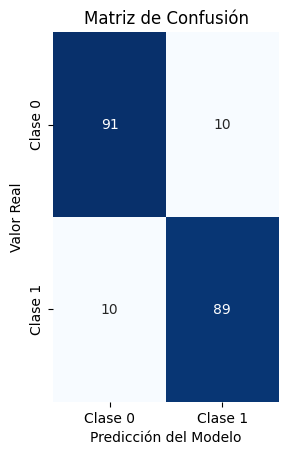

In [11]:
plt.subplot(1, 2, 1)
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Clase 0', 'Clase 1'],
            yticklabels=['Clase 0', 'Clase 1'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')

Text(0, 0.5, 'Puntuación (0 a 1)')

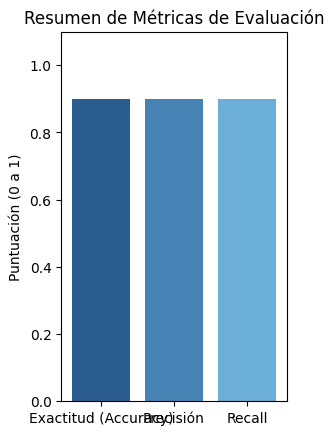

In [12]:
plt.subplot(1, 2, 2)
metricas_nombres = ['Exactitud (Accuracy)', 'Precisión', 'Recall']
metricas_valores = [accuracy, precision, recall]

bars = plt.bar(metricas_nombres, metricas_valores, color=['#2b5c8f', '#4682b4', '#6baed6'])
plt.ylim(0, 1.1)
plt.title('Resumen de Métricas de Evaluación')
plt.ylabel('Puntuación (0 a 1)')

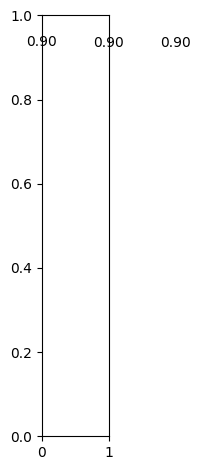

In [13]:
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()